# Spacing SF: Examining Inequity in Access to Essential Amenities


#### Group 9: Dynamic Duo!

#####Brittany Vang
#####Taylor Vassar

##### Description: San Francisco's neighborhoods distribute resources unevenly across income levels. This project maps food, transit, and school access. Lower-income tracts may face multiple overlapping resource gaps. We use weighted measures. The goal is to reveal compounded spatial disadvantage.


In [ ]:
# set working directory: GitHub Repo

!git clone https://github.com/taylorvassar/CYPLAN_255_FINAL.git

fatal: destination path 'CYPLAN_255_FINAL' already exists and is not an empty directory.


In [ ]:
%cd /content/CYPLAN_255_FINAL/
!git pull

/content/CYPLAN_255_FINAL
Already up to date.


In [ ]:
# Import necessary libraries
import os
import numpy as np
%matplotlib inline
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from shapely.geometry import Point
from datetime import datetime
from shapely import wkt

In [ ]:
# SF bounding box
bbox = -122.5145, 37.7085, -122.3716, 37.8092    #referenced from W11 S1 activity

#### SF Census Data/Geometry

In [ ]:
#Create SF boundary and clip income information
sf_tracts = pd.read_csv("/content/CYPLAN_255_FINAL/data/raw/Census_2020__Tracts_for_San_Francisco_20260327.csv")

sf_tracts.head()

,the_geom,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,data_loaded_at,data_as_of
0,MULTIPOLYGON (((-122.427223 37.715548999999996...,6,75,980501,6075980501,9805.01,Census Tract 9805.01,G5020,S,"1,471,536","9,769",37.716208,-122.419346,2022 Mar 04 12:00:00 AM,2021 Feb 01 12:00:00 AM
1,"MULTIPOLYGON (((-122.453206 37.768249, -122.45...",6,75,17102,6075017102,171.02,Census Tract 171.02,G5020,S,"294,894",0,37.765435,-122.450475,2022 Mar 04 12:00:00 AM,2021 Feb 01 12:00:00 AM
2,"MULTIPOLYGON (((-122.414995 37.787454, -122.41...",6,75,12302,6075012302,123.02,Census Tract 123.02,G5020,S,"92,653",0,37.787022,-122.412097,2022 Mar 04 12:00:00 AM,2021 Feb 01 12:00:00 AM
3,"MULTIPOLYGON (((-122.432351 37.773779, -122.43...",6,75,16801,6075016801,168.01,Census Tract 168.01,G5020,S,"226,534",0,37.771331,-122.429013,2022 Mar 04 12:00:00 AM,2021 Feb 01 12:00:00 AM
4,"MULTIPOLYGON (((-122.41246100000001 37.791627,...",6,75,11902,6075011902,119.02,Census Tract 119.02,G5020,S,"93,053",0,37.790996,-122.409807,2022 Mar 04 12:00:00 AM,2021 Feb 01 12:00:00 AM


In [ ]:
#check to see if sf_tracts has geographic info
sf_tracts.columns.tolist()

['the_geom',
 'STATEFP',
 'COUNTYFP',
 'TRACTCE',
 'GEOID',
 'NAME',
 'NAMELSAD',
 'MTFCC',
 'FUNCSTAT',
 'ALAND',
 'AWATER',
 'INTPTLAT',
 'INTPTLON',
 'data_loaded_at',
 'data_as_of']

In [ ]:
# check the data type for 'the_geom'
print(type(sf_tracts['the_geom'][0])) # type is a str, will need to change to a geometry object

<class 'str'>


In [ ]:
# convert sf_tracts to a geodataframe
sf_tracts_gdf = gpd.GeoDataFrame(sf_tracts, geometry=gpd.GeoSeries.from_wkt(sf_tracts['the_geom']), crs=4326)

#reproject to espg:2227, which is best for city/county data, using US ft
sf_tracts_gdf = sf_tracts_gdf.to_crs(epsg=2227)

In [ ]:
# Compute total non-NaNs per column
valid_counts = sf_tracts_gdf.count()
valid_percentages = (valid_counts / len(sf_tracts_gdf)) * 100

In [ ]:
summary_df = pd.DataFrame({
    'Non-NaN Count': valid_counts,
    'Valid %': valid_percentages.round(1)
})

print("******* Column Summary *******")
summary_df

# no missing values!

******* Column Summary *******


,Non-NaN Count,Valid %
the_geom,244,100.0
STATEFP,244,100.0
COUNTYFP,244,100.0
TRACTCE,244,100.0
GEOID,244,100.0
NAME,244,100.0
NAMELSAD,244,100.0
MTFCC,244,100.0
FUNCSTAT,244,100.0
ALAND,244,100.0


<Axes: >

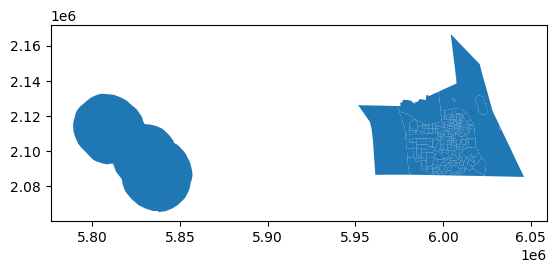

In [ ]:
#plot to check
sf_tracts_gdf.plot()

# the blobs on the left are the Farallon Islands - technically part of SF
# east side includes Treasure Island/Yerba Buena

<Axes: >

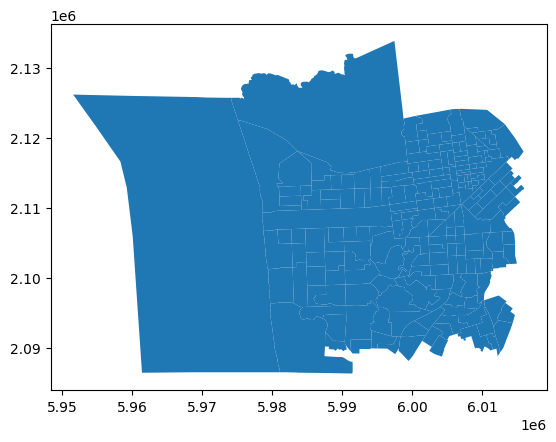

In [ ]:
# filter out Farallons, Treasure Island, and Yerba Buena Island using centroid bounds
sf_tracts_gdf = sf_tracts_gdf[
    (sf_tracts_gdf.geometry.centroid.x > 5.90e6) &  # remove Farallons
    (sf_tracts_gdf.geometry.centroid.x < 6.015e6) &  # remove Treasure/Yerba Buena (too far east)
    (sf_tracts_gdf.geometry.centroid.y > 2.09e6)    # remove southern outliers

]

sf_tracts_gdf.plot()


In [ ]:
# check area
print(sf_tracts_gdf.geometry.area.describe())

count    2.110000e+02
mean     1.012556e+07
std      5.605175e+07
min      2.829902e+05
25%      2.029079e+06
50%      3.527039e+06
75%      5.830933e+06
max      7.634722e+08
dtype: float64


          GEOID           NAMELSAD      ALAND      AWATER
88   6075990100  Census Tract 9901          0  70,939,179
123  6075060100   Census Tract 601  6,102,011  20,352,676


<Axes: >

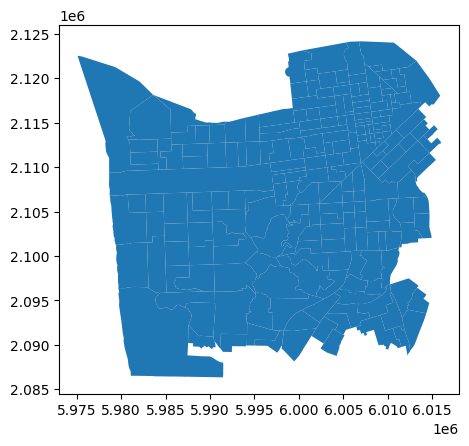

In [ ]:
# filter out the large outliers/water tracts on the west side
print(sf_tracts_gdf[sf_tracts_gdf.geometry.area > 1e8][['GEOID', 'NAMELSAD', 'ALAND', 'AWATER']])

sf_gdf = sf_gdf[~sf_gdf['GEOID'].isin(['6075990100', '6075060100'])] #remove water areas/tracts
sf_gdf.plot()

Income

In [ ]:
# load in census data for median income - ACS 5 year estimates, 2024
median_inc_sf = pd.read_csv("/content/CYPLAN_255_FINAL/data/raw/ACSDT5Y2024.B19013-Data.csv")

# preview
median_inc_sf.head()

,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4
0,Geography,Geographic Area Name,Estimate!!Median household income in the past ...,Margin of Error!!Median household income in th...,NaN
1,1400000US06075010101,Census Tract 101.01; San Francisco County; Cal...,89022,40627,NaN
2,1400000US06075010102,Census Tract 101.02; San Francisco County; Cal...,102826,55857,NaN
3,1400000US06075010201,Census Tract 102.01; San Francisco County; Cal...,156017,4484,NaN
4,1400000US06075010202,Census Tract 102.02; San Francisco County; Cal...,176958,57906,NaN


In [ ]:
# inspect
print(median_inc_sf.columns.to_list())
print(median_inc_sf.info())

['GEO_ID', 'NAME', 'B19013_001E', 'B19013_001M', 'Unnamed: 4']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   GEO_ID       245 non-null    object 
 1   NAME         245 non-null    object 
 2   B19013_001E  245 non-null    object 
 3   B19013_001M  245 non-null    object 
 4   Unnamed: 4   0 non-null      float64
dtypes: float64(1), object(4)
memory usage: 9.7+ KB
None


In [ ]:
# clean the dataset
median_inc_sf = median_inc_sf.drop(columns=['B19013_001M', 'Unnamed: 4']) # don't need empty column or margin of error
median_inc_sf = median_inc_sf.rename(columns={'B19013_001E' : 'median_inc'}) #keep estimate variable and rename

# check to see that GEO_ID matches with sf_tracts_gdf
print(median_inc_sf['GEO_ID'].iloc[1])
print(sf_tracts_gdf['GEOID'].iloc[0])

# geoids do not match
# make the geoids match and check again
median_inc_sf['GEO_ID'] = median_inc_sf['GEO_ID'].str.replace('1400000US0', '') #remove non-necessary geo identifiers and keep to 10 digits
print(median_inc_sf['GEO_ID'].iloc[1])
print(sf_tracts_gdf['GEOID'].iloc[0])

1400000US06075010101
6075017102
6075010101
6075017102


In [ ]:
# join the sf geometry with the acs median income dataset
sf_tracts_gdf['GEOID'] = sf_tracts_gdf['GEOID'].astype(str) #change GEOID type to str from int
sf_gdf = sf_tracts_gdf.merge(median_inc_sf, left_on='GEOID', right_on='GEO_ID', how='left')

# check
sf_gdf[['GEOID', 'median_inc']].head()

,GEOID,median_inc
0,6075017102,173594
1,6075012302,44954
2,6075016801,123147
3,6075011902,75625
4,6075012202,57897


In [ ]:
# Compute total non-NaNs per column
valid_counts = sf_gdf.count()
valid_percentages = (valid_counts / len(sf_gdf)) * 100

In [ ]:
summary_df = pd.DataFrame({
    'Non-NaN Count': valid_counts,
    'Valid %': valid_percentages.round(1)
})

print("******* Column Summary *******")
summary_df

# no missing values!

******* Column Summary *******


,Non-NaN Count,Valid %
the_geom,209,100.0
STATEFP,209,100.0
COUNTYFP,209,100.0
TRACTCE,209,100.0
GEOID,209,100.0
NAME_x,209,100.0
NAMELSAD,209,100.0
MTFCC,209,100.0
FUNCSTAT,209,100.0
ALAND,209,100.0


<Axes: >

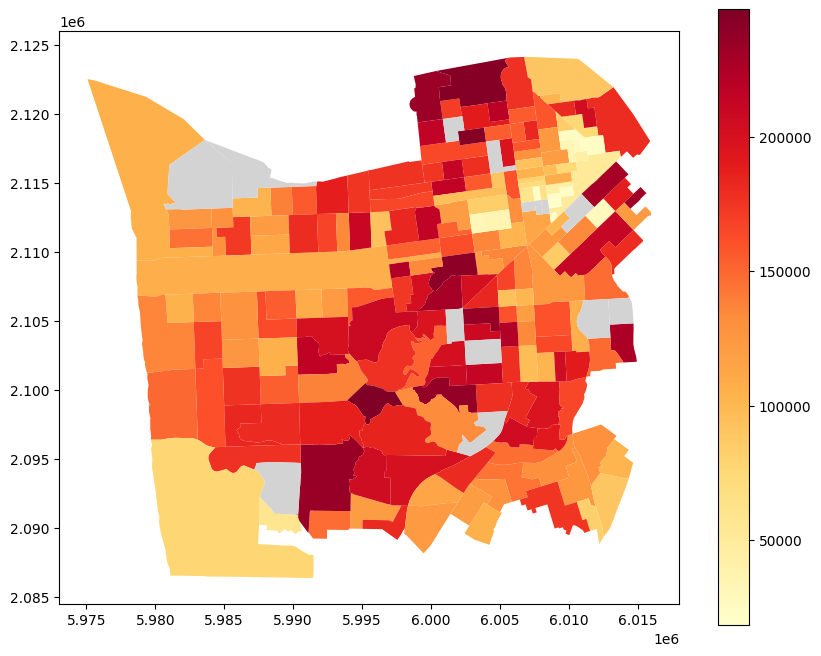

In [ ]:
# convert median income to numeric
sf_gdf['median_inc'] = pd.to_numeric(sf_gdf['median_inc'], errors='coerce')

# filter out unwanted tracts (islands and water tracts)
sf_gdf = sf_gdf[
    (sf_gdf.geometry.centroid.x > 5.90e6) &       # removes Farallons
    (sf_gdf.geometry.centroid.x < 6.015e6) &      # removes Treasure/Yerba Buena
    (~sf_gdf['GEOID'].isin(['6075990100', '6075060100']))  # removes water tracts
]
# plot
sf_gdf.plot(column='median_inc', cmap='YlOrRd', legend=True, figsize=(10,8), missing_kwds={'color': 'lightgrey'})

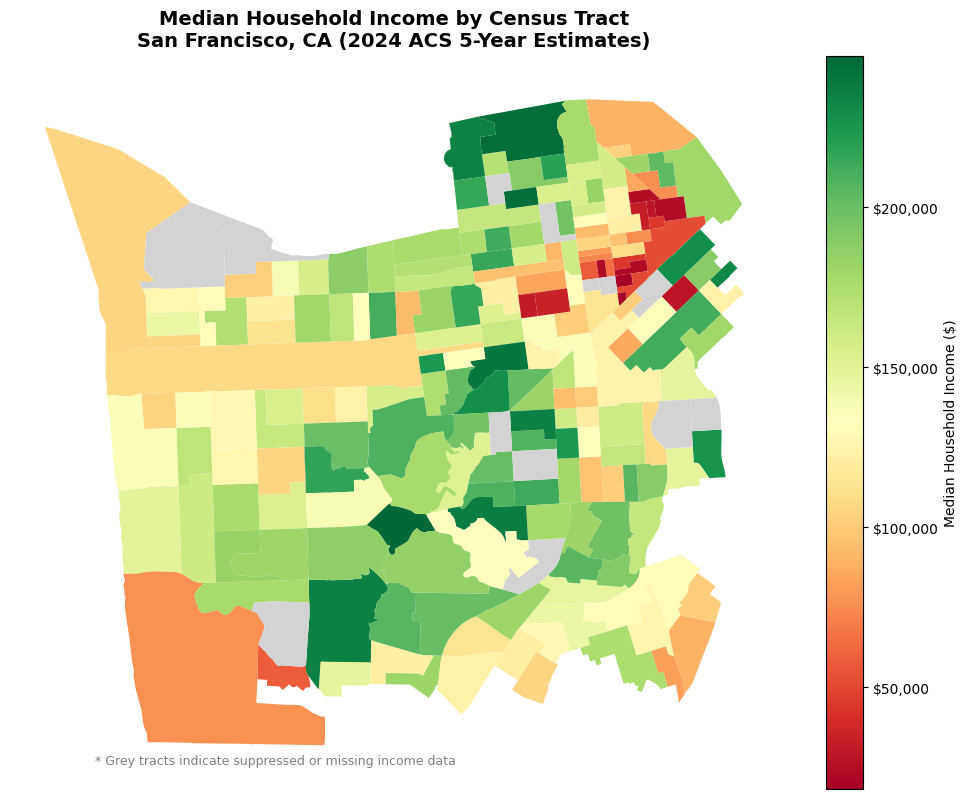

In [ ]:

# plot
fig, ax = plt.subplots(figsize=(10, 8))

sf_gdf.plot(
    column='median_inc',
    cmap='RdYlGn',
    legend=True,
    ax=ax,
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
    legend_kwds={
        'label': 'Median Household Income ($)',
        'format': '${x:,.0f}'
    }
)

ax.set_axis_off()
ax.set_title('Median Household Income by Census Tract\nSan Francisco, CA (2024 ACS 5-Year Estimates)',
             fontsize=14, fontweight='bold', pad=15)

fig.text(0.1, 0.05, '* Grey tracts indicate suppressed or missing income data',
         fontsize=9, color='grey')

plt.tight_layout()
plt.show()

In [ ]:
# compute summary statistics
sf_gdf['median_inc'].describe()

,median_inc
count,195.000000
mean,145087.148718
std,54367.356035
min,18217.000000
25%,107135.500000
50%,152097.000000
75%,182114.000000
max,247500.000000


In [ ]:
# save cleaned file to processed
sf_gdf.to_file('/content/CYPLAN_255_FINAL/data/processed/sf_gdf.geojson', driver ='GeoJSON')

#### Amenity Type: Food

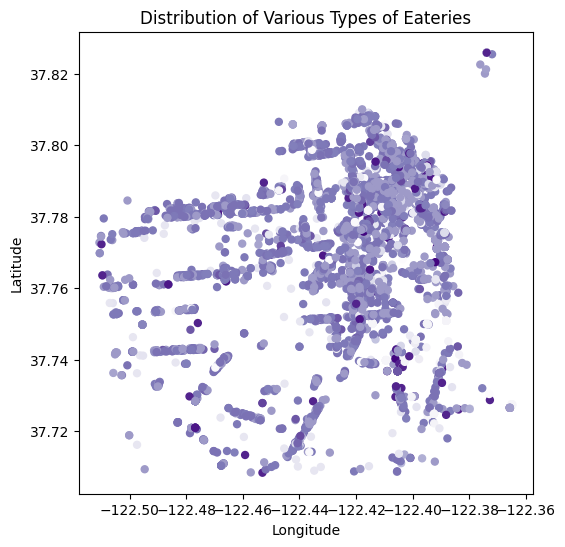

In [ ]:
# Cleaning 'Active Food Services' Dataset
os.listdir('/content/CYPLAN_255_FINAL')
active_food_services = pd.read_csv('/content/CYPLAN_255_FINAL/data/raw/active_food_services.csv', low_memory=False)

# remove unnecessary columns
active_food_services = active_food_services.drop(['UniqueID', 'Business Account Number', 'Location Id', 'Ownership Name', 'State', 'Source Zipcode', 'Administratively Closed', 'Mail Address', 'Mail City', 'Mail Zipcode', 'NAICS Code',
 'Parking Tax', 'Transient Occupancy Tax', 'data_as_of', 'data_loaded_at'], axis=1)

# standardize columns names
active_food_services.columns = active_food_services.columns.str.lower().str.replace(" ", "_").str.replace("-","")

# We only want locations that are located in SF and are NOT closed.
active_food_services = active_food_services[(active_food_services['city'] == 'San Francisco') & (active_food_services['business_end_date'].isna())]

# get rid of business location columns
active_food_services = active_food_services[active_food_services['business_location'].notna()]

#
active_food_services['business_location'] = active_food_services['business_location'].apply(wkt.loads)

gdf = gpd.GeoDataFrame(active_food_services, geometry='business_location', crs='EPSG:4326')

fig, ax = plt.subplots(figsize=(10, 6))
gdf.plot(
    ax=ax,
  column='lic_code_description',
    cmap='Purples',
    legend=False,
    markersize=25
)
plt.title('Distribution of Various Types of Eateries')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
active_food_services.shape

(10009, 18)

/tmp/ipykernel_51550/2403560866.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  mobiles['ExpirationDate'] = pd.to_datetime(mobiles['ExpirationDate'])


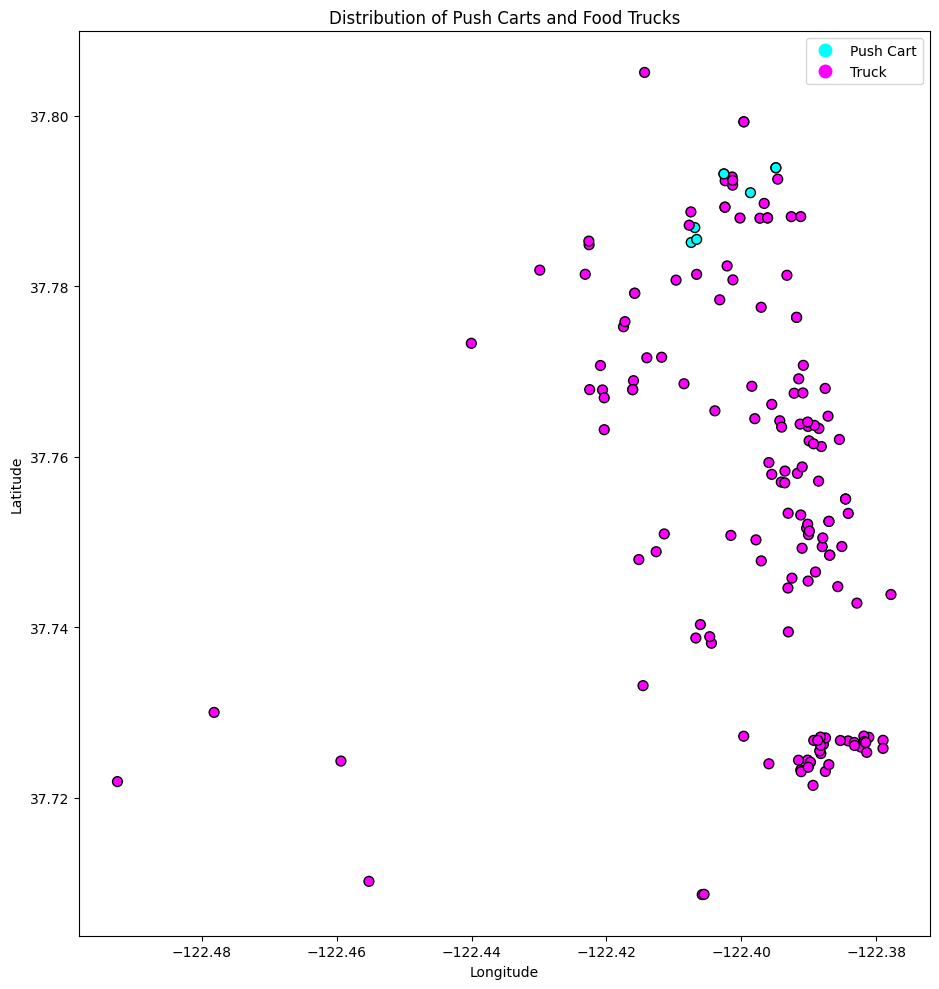

In [ ]:
# Cleaning and Examining Mobile Food Services Dataset
mobiles = pd.read_csv("/content/CYPLAN_255_FINAL/data/raw/Mobile_Food_Facility_Permit_20260401.csv")

# We only want the Applicant, FacilityType, ExpirationDate, Latitude, Longitude, Address
# Then, sort by expiration date - we only want dates that have not passed yet
mobiles = mobiles[['Applicant', 'FacilityType', 'ExpirationDate', 'Latitude', 'Longitude', 'Address']].sort_values('ExpirationDate', ascending=False)

# we want actual dates, not strings
mobiles['ExpirationDate'] = pd.to_datetime(mobiles['ExpirationDate'])

# only consider permits that have not expired, starting from today (4/3/26)
today = '2026-04-03'
date_mask = (mobiles['ExpirationDate'] >= today)
active_mobiles = mobiles.loc[date_mask].reset_index(drop=True)

# standardize column names!
active_mobiles.columns = active_mobiles.columns.str.lower().str.replace("yt","y_t").str.replace("nd","n_d")

# exclude ambiguous coordinates
active_mobiles = active_mobiles[(active_mobiles['latitude'] != 0) & (active_mobiles['longitude'] != 0)]



# plot distribution of food trucks and mobile carts
geometry = [Point(xy) for xy in zip(active_mobiles['longitude'], active_mobiles['latitude'])]

gdf = gpd.GeoDataFrame(active_mobiles, geometry=geometry, crs='EPSG:4326')

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(
    ax=ax,
    column='facility_type',
    cmap='cool',
    markersize=50,
    alpha=1.0,
    legend=True,
    edgecolor='black'
)

plt.title('Distribution of Push Carts and Food Trucks')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

In [ ]:
len(active_mobiles)

160

In [ ]:
len(active_food_services['lic_code_description'])

10009

#### Amenity Type: Transit

In [ ]:
#enter code for transit amenity

#### Amenity Type: Schools

In [ ]:
# Load file from github repo and inspect
schools_df_raw = pd.read_excel("/content/CYPLAN_255_FINAL/data/raw/EDGE_GEOCODE_PUBLICSCH_2425.xlsx")

schools_df_raw.head()

,NCESSCH,LEAID,NAME,OPSTFIPS,STREET,CITY,STATE,ZIP,STFIP,CNTY,...,LON,CBSA,NMCBSA,CBSATYPE,CSA,NMCSA,CD,SLDL,SLDU,SCHOOLYEAR
0,10000500870,100005,Albertville Middle School,1,600 E Alabama Ave,Albertville,AL,35950,1,1095,...,-86.206200,10700,"Albertville, AL",2,290,"Huntsville-Decatur-Albertville, AL-TN",104,01026,01009,2024-2025
1,10000500871,100005,Albertville High School,1,402 E McCord Ave,Albertville,AL,35950,1,1095,...,-86.204911,10700,"Albertville, AL",2,290,"Huntsville-Decatur-Albertville, AL-TN",104,01026,01009,2024-2025
2,10000500879,100005,Albertville Intermediate School,1,901 W McKinney Ave,Albertville,AL,35950,1,1095,...,-86.220154,10700,"Albertville, AL",2,290,"Huntsville-Decatur-Albertville, AL-TN",104,01026,01009,2024-2025
3,10000500889,100005,Albertville Elementary School,1,145 West End Drive,Albertville,AL,35950,1,1095,...,-86.221806,10700,"Albertville, AL",2,290,"Huntsville-Decatur-Albertville, AL-TN",104,01026,01009,2024-2025
4,10000501616,100005,Albertville Kindergarten and PreK,1,257 Country Club Rd,Albertville,AL,35951,1,1095,...,-86.193056,10700,"Albertville, AL",2,290,"Huntsville-Decatur-Albertville, AL-TN",104,01026,01009,2024-2025


In [ ]:
#look to see what columns are included
schools_df_raw.columns

In [ ]:
# create a cleaned version of the schools_df_raw by keeping only SF schools
schools_sf = schools_df_raw.copy() #make copy
schools_sf = schools_sf[schools_sf['NMCNTY'] == 'San Francisco County'] #keep SF County schools only

#check the school types and filter
print(schools_sf['LOCALE'].unique)

#remove any duplicates
schools_sf = schools_sf.drop_duplicates()

#standardize column names and rename
schools_sf = schools_sf.rename(columns={
                               'NCESSCH': 'school_id',
                               'NAME': 'school_name',
                               'LAT': 'latitude',
                               'LON': 'longitude',
                               'STREET': 'address',
                               'ZIP': 'zipcode'})
#keep only the desired columns
schools_sf = schools_sf[['school_id',
                         'school_name',
                         'address',
                         'CITY',
                         'zipcode',
                         'latitude',
                         'longitude']]

# check to see the total schools and display first 5 rows
print(f"Total SF schools: {len(schools_sf)}")
print(schools_sf[['school_name', 'latitude', 'longitude']].head())

<bound method Series.unique of 6251     11
6484     11
6627     11
6874     11
6976     11
         ..
14279    11
16072    11
16073    11
16074    11
16075    11
Name: LOCALE, Length: 132, dtype: int64>
Total SF schools: 132
                                 school_name   latitude   longitude
6251                San Francisco County ROP  37.775628 -122.483841
6484                 KIPP Bayview Elementary  37.718421 -122.389474
6627          KIPP San Francisco Bay Academy  37.783440 -122.437375
6874                          Gateway Middle  37.779437 -122.435995
6976  KIPP San Francisco College Preparatory  37.732324 -122.382591


In [ ]:
# used the cleaned school dataframe to convert to geodataframe using long, lat
schools_sf_gdf = gpd.GeoDataFrame(
    schools_sf,
    geometry=gpd.points_from_xy(schools_sf['longitude'], schools_sf['latitude']),
    crs=4326
)

#reproject to 2227
schools_sf_gdf = schools_sf_gdf.to_crs(epsg=2227)

In [ ]:
# Compute total non-NaNs per column
valid_counts = schools_sf_gdf.count()
valid_percentages = (valid_counts / len(schools_sf_gdf)) * 100

In [ ]:
summary_df = pd.DataFrame({
    'Non-NaN Count': valid_counts,
    'Valid %': valid_percentages.round(1)
})

print("******* Column Summary *******")
summary_df

# no missing values!

******* Column Summary *******


,Non-NaN Count,Valid %
school_id,132,100.0
school_name,132,100.0
address,132,100.0
CITY,132,100.0
zipcode,132,100.0
latitude,132,100.0
longitude,132,100.0
geometry,132,100.0


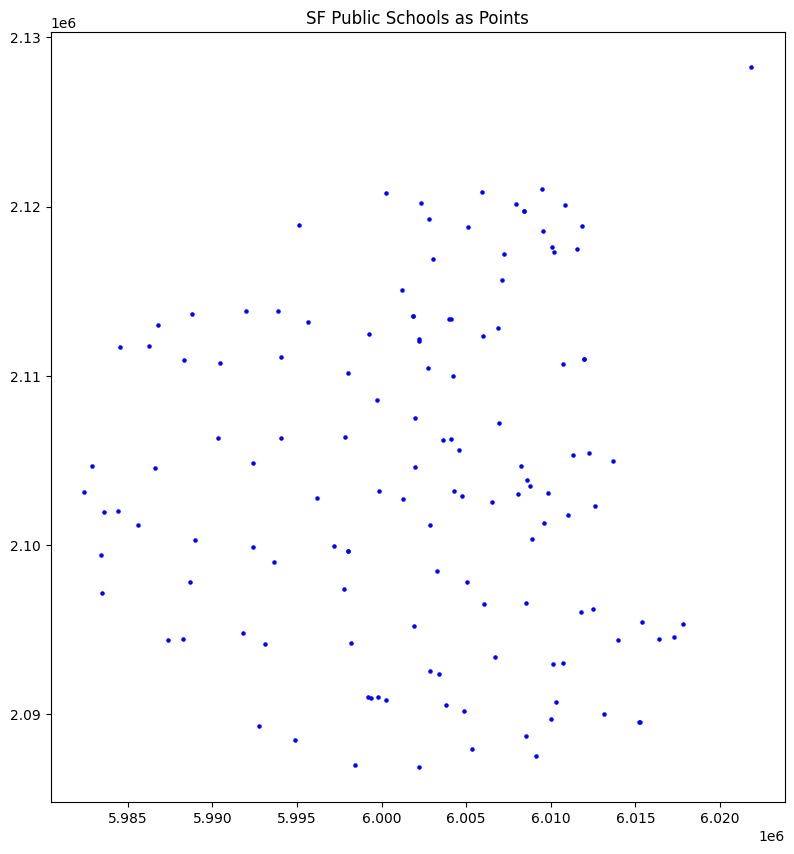

In [ ]:
# quick plot to check points
fig, ax = plt.subplots(figsize=(10,10))
schools_sf_gdf.plot(ax=ax, color='blue', markersize=5)
ax.set_title('SF Public Schools as Points')
plt.show()

In [ ]:
# check crs for sf_gdf and schools_sf_gdf
print(schools_sf_gdf.crs)
print(sf_gdf.crs)

EPSG:2227
EPSG:2227


In [ ]:
# save cleaned file to processed
schools_sf_gdf.to_file('/content/CYPLAN_255_FINAL/data/processed/schools_sf_gdf.geojson', driver='GeoJSON')

In [ ]:
# spatial join to count schools per tract
schools_in_tracts = gpd.sjoin(schools_sf_gdf, sf_gdf[["geometry", "GEOID"]],
                               how="left", predicate="within")

school_counts = (schools_in_tracts #count how many schools in each tract
                 .groupby("GEOID")
                 .size()
                 .reset_index(name="school_count"))

sf_gdf = sf_gdf.merge(school_counts, on="GEOID", how="left") #bring counts to tract table
sf_gdf["school_count"] = sf_gdf["school_count"].fillna(0) #tract with no schools, replace NaN with 0

# glance
sf_gdf[["GEOID", "school_count"]].head(10)

,GEOID,school_count
0,6075017102,1.0
1,6075012302,0.0
2,6075016801,0.0
3,6075011902,0.0
4,6075012202,0.0
5,6075012601,0.0
6,6075013102,0.0
7,6075012602,0.0
8,6075015201,0.0
9,6075012902,2.0


In [ ]:
# check that the merged dataset still contains all the schools
print(sf_gdf["school_count"].sum())


115.0


In [ ]:
# calculate distance to nearest school per tract centroid
def nearest_school_distance(tract_centroid, school_geoms):
    """Return distance in meters to nearest school from a point."""
    #compute distance from centroid to each school, look at the closest distance
    distances = school_geoms.distance(tract_centroid)
    return distances.min()

sf_gdf["centroid"] = sf_gdf.geometry.centroid #get center point so we can use the tract polygon as the representing location
sf_gdf["dist_nearest_school_ft"] = sf_gdf["centroid"].apply(
    lambda pt: nearest_school_distance(pt, schools_sf_gdf.geometry) #get distance to each nearest school for each centroid, row-by-row
)
sf_gdf["dist_nearest_school_ft"].describe()

#convert feet to meters for readability
sf_gdf["dist_nearest_school_m"] = sf_gdf["dist_nearest_school_ft"] * 0.3048

# check
sf_gdf["dist_nearest_school_m"].describe()

,dist_nearest_school_m
count,209.000000
mean,404.923665
std,270.260128
min,27.977680
25%,221.792589
50%,365.718391
75%,521.282014
max,2146.064932


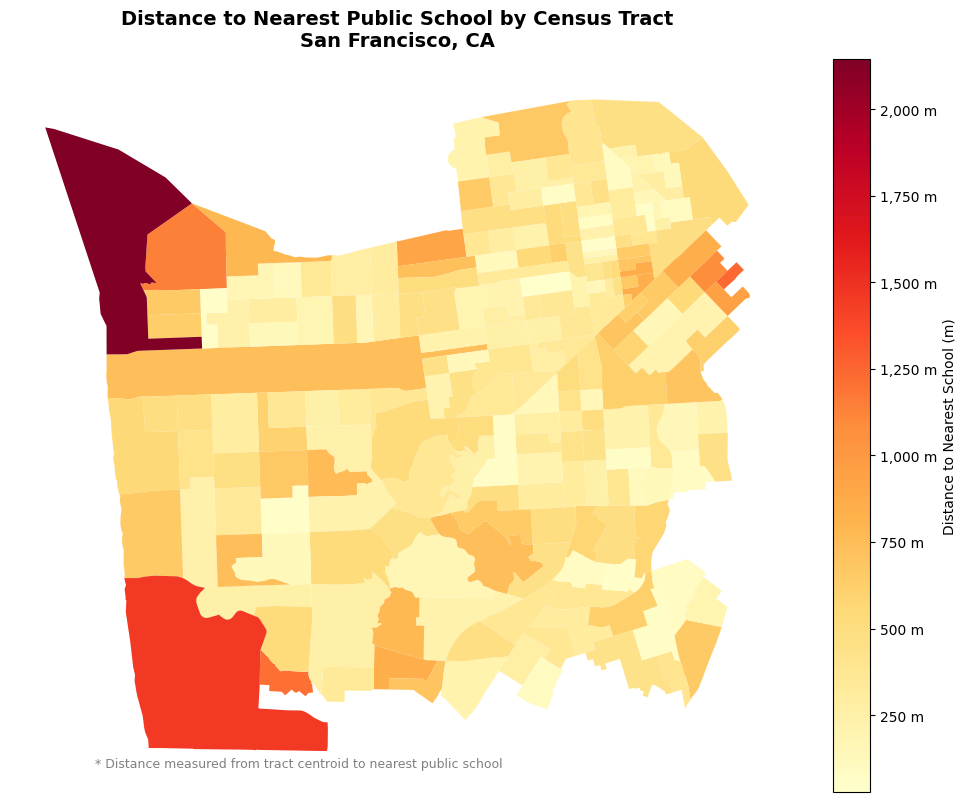

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

sf_gdf.plot(
    column='dist_nearest_school_m',
    cmap='YlOrRd',
    legend=True,
    ax=ax,
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
    legend_kwds={
        'label': 'Distance to Nearest School (m)',
        'format': '{x:,.0f} m'
    }
)

ax.set_axis_off()
ax.set_title('Distance to Nearest Public School by Census Tract\nSan Francisco, CA',
             fontsize=14, fontweight='bold', pad=15)

fig.text(0.1, 0.05, '* Distance measured from tract centroid to nearest public school',
         fontsize=9, color='grey')

plt.tight_layout()
plt.show()

In [ ]:
# summary statistics for distance
sf_gdf["dist_nearest_school_m"].describe()

,dist_nearest_school_m
count,209.000000
mean,404.923665
std,270.260128
min,27.977680
25%,221.792589
50%,365.718391
75%,521.282014
max,2146.064932
